In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv("marketing_campaign_dataset_50k.csv")

print("Dataset Shape:", df.shape)
print(df.head())
print(df.info())

Dataset Shape: (50000, 15)
      user_id  age  gender    country timezone   device campaign_id  \
0  USR_000001   56    Male  Australia     AEDT  Desktop     CMP_139   
1  USR_000002   46    Male      India      IST  Desktop     CMP_166   
2  USR_000003   32    Male  Australia     AEDT  Desktop     CMP_180   
3  USR_000004   60  Female     Canada      EST  Desktop     CMP_116   
4  USR_000005   25  Female  Australia     AEDT   Mobile     CMP_192   

  campaign_type            send_time  send_hour  open_rate  click_rate  \
0        Manual  2024-03-18 15:38:00         15     0.2273      0.0110   
1            AI  2024-03-03 03:12:00          3     0.2155      0.0048   
2            AI  2024-03-25 18:08:00         18     0.6407      0.1108   
3            AI  2024-03-08 17:08:00         17     0.0965      0.0348   
4        Manual  2024-03-07 18:11:00         18     0.5178      0.0297   

   conversion_rate delivery_status  engagement_score  
0           0.0001       Delivered            

In [ ]:
df['send_time'] = pd.to_datetime(df['send_time'])
if 'send_hour' not in df.columns:
    df['send_hour'] = df['send_time'].dt.hour
print("\nMissing Values:\n", df.isnull().sum())
df = df.drop_duplicates()


Missing Values:
 user_id             0
age                 0
gender              0
country             0
timezone            0
device              0
campaign_id         0
campaign_type       0
send_time           0
send_hour           0
open_rate           0
click_rate          0
conversion_rate     0
delivery_status     0
engagement_score    0
dtype: int64



Best Sending Time per Timezone:
    timezone  send_hour  open_rate
18     AEDT         18   0.343110
43      EST         19   0.335998
68      GMT         20   0.339935
83      IST         11   0.343224


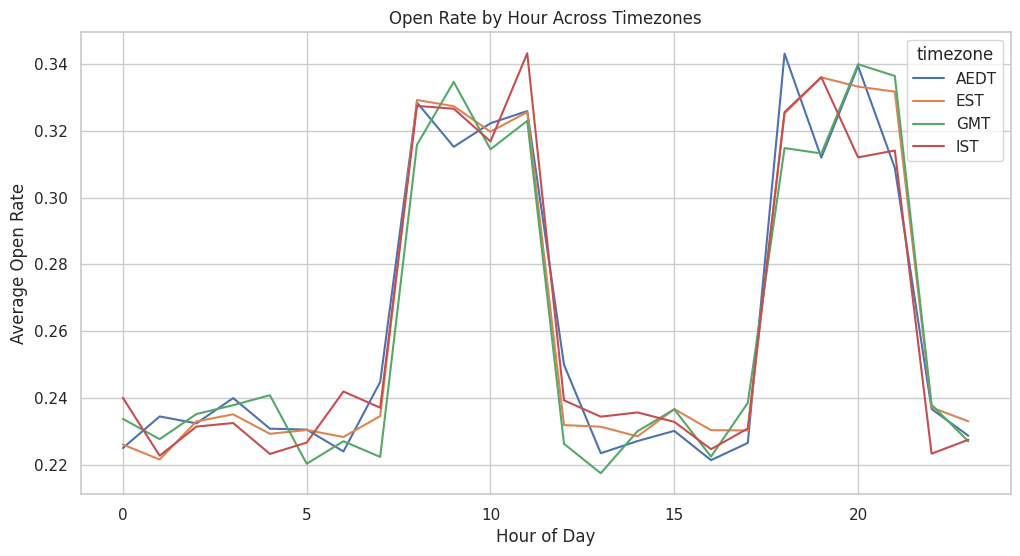

In [ ]:
tz_analysis = df.groupby(['timezone','send_hour'])['open_rate'].mean().reset_index()
best_tz = tz_analysis.loc[tz_analysis.groupby('timezone')['open_rate'].idxmax()]
print("\nBest Sending Time per Timezone:\n", best_tz)
plt.figure(figsize=(12,6))
sns.lineplot(data=tz_analysis, x='send_hour', y='open_rate', hue='timezone')
plt.title("Open Rate by Hour Across Timezones")
plt.xlabel("Hour of Day")
plt.ylabel("Average Open Rate")
plt.show()


Best Global Sending Hours:
 send_hour
20    0.331616
11    0.328318
18    0.326821
9     0.326464
19    0.326417
Name: open_rate, dtype: float64


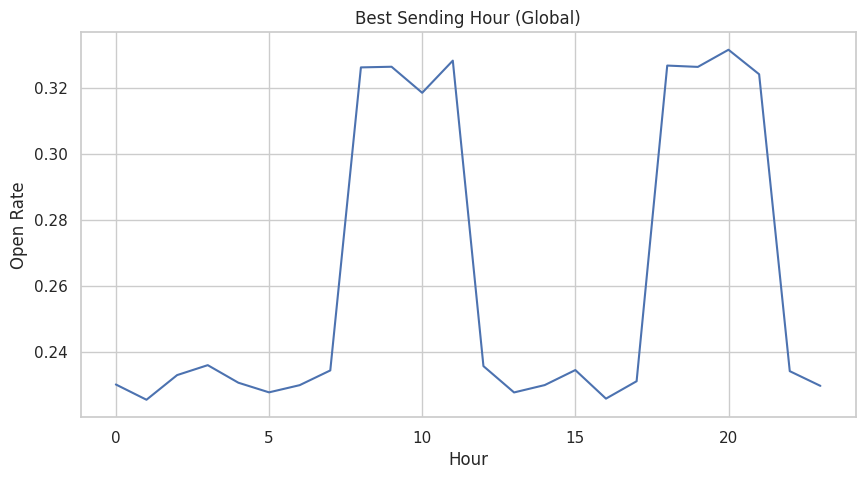

In [ ]:
best_time = df.groupby('send_hour')['open_rate'].mean().sort_values(ascending=False)
print("\nBest Global Sending Hours:\n", best_time.head())
plt.figure(figsize=(10,5))
sns.lineplot(x=best_time.index, y=best_time.values)
plt.title("Best Sending Hour (Global)")
plt.xlabel("Hour")
plt.ylabel("Open Rate")
plt.show()


Campaign Performance:
                open_rate  click_rate  conversion_rate
campaign_type                                        
AI              0.276991    0.030629         0.001222
Manual          0.240918    0.023410         0.000942


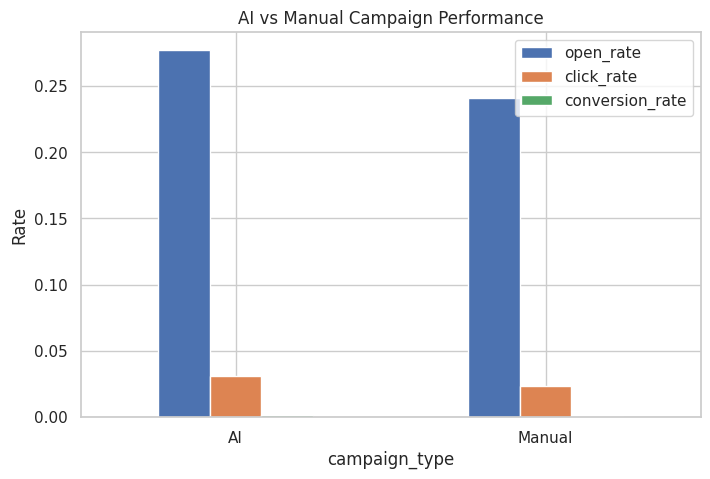

In [ ]:
campaign_perf = df.groupby('campaign_type')[['open_rate','click_rate','conversion_rate']].mean()
print("\nCampaign Performance:\n", campaign_perf)
campaign_perf.plot(kind='bar', figsize=(8,5))
plt.title("AI vs Manual Campaign Performance")
plt.ylabel("Rate")
plt.xticks(rotation=0)
plt.show()


Persona Summary:
          open_rate  click_rate  conversion_rate
persona                                        
0         0.167896    0.012927         0.000454
1         0.511261    0.137405         0.010587
2         0.430322    0.045009         0.001288


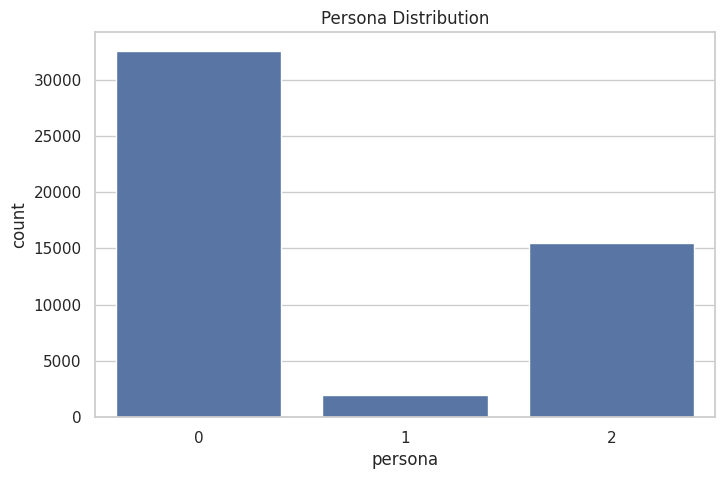

In [ ]:
features = df[['open_rate','click_rate','conversion_rate']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
kmeans = KMeans(n_clusters=3, random_state=42)
df['persona'] = kmeans.fit_predict(scaled_features)
persona_summary = df.groupby('persona')[['open_rate','click_rate','conversion_rate']].mean()
print("\nPersona Summary:\n", persona_summary)
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='persona')
plt.title("Persona Distribution")
plt.show()


Device Performance:
 device
Desktop    0.249927
Mobile     0.273319
Tablet     0.247987
Name: open_rate, dtype: float64


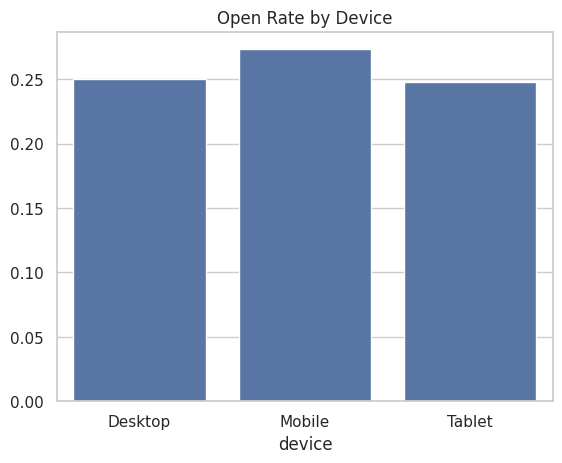

In [ ]:
if 'device' in df.columns:
    device_perf = df.groupby('device')['open_rate'].mean()
    print("\nDevice Performance:\n", device_perf)

    sns.barplot(x=device_perf.index, y=device_perf.values)
    plt.title("Open Rate by Device")
    plt.show()


In [ ]:
delivery = df['delivery_status'].value_counts(normalize=True)
print("\nDelivery Status:\n", delivery)


Delivery Status:
 delivery_status
Delivered    0.93880
Bounced      0.04018
Failed       0.02102
Name: proportion, dtype: float64
